Notebook — Fraud Detection using Supervised Learning
1. Importação de Bibliotecas


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

2. Carregamento do Dataset

In [5]:

df = pd.read_csv(r"C:\Users\fernanda\Documents\Projetos Pessoal\trabalhos pós\pd cluster 3\archive (3)\creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


3. Análise Inicial dos Dados

In [6]:

df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


4. Distribuição da Variável Alvo

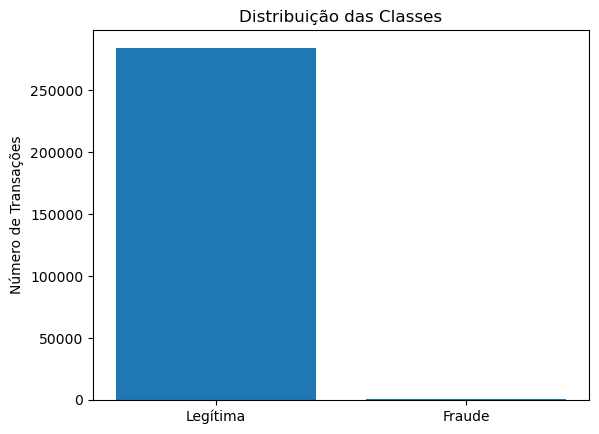

In [7]:

df["Class"].value_counts()
fraud_counts = df["Class"].value_counts()

plt.bar(["Legítima","Fraude"], fraud_counts)
plt.title("Distribuição das Classes")
plt.ylabel("Número de Transações")
plt.show()

5. Separação de Features e Target

In [8]:

X = df.drop("Class", axis=1)
y = df["Class"]

6. Normalização dos Dados

In [9]:


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

7. Separação Treino/Teste

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

8. Modelo Baseline — Perceptron

In [11]:


perceptron = Perceptron()

perceptron.fit(X_train, y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


Predição

In [12]:

y_pred = perceptron.predict(X_test)

Avaliação do Baseline

In [13]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.9989817773252344
Precision: 0.6851851851851852
Recall: 0.7551020408163265
F1-score: 0.7184466019417476


Interpretação dos Coeficientes

In [14]:

weights = perceptron.coef_[0]

coef_df = pd.DataFrame({
    "feature": X.columns,
    "weight": weights
})

coef_df.sort_values(by="weight", ascending=False).head()

,feature,weight
1,V1,58.525438
4,V4,47.029131
12,V12,26.546673
21,V21,21.378632
8,V8,9.914778


9. Modelo Árvore de Decisão

In [15]:

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Predição

In [16]:

y_pred_tree = tree.predict(X_test)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



Visualização da Árvore

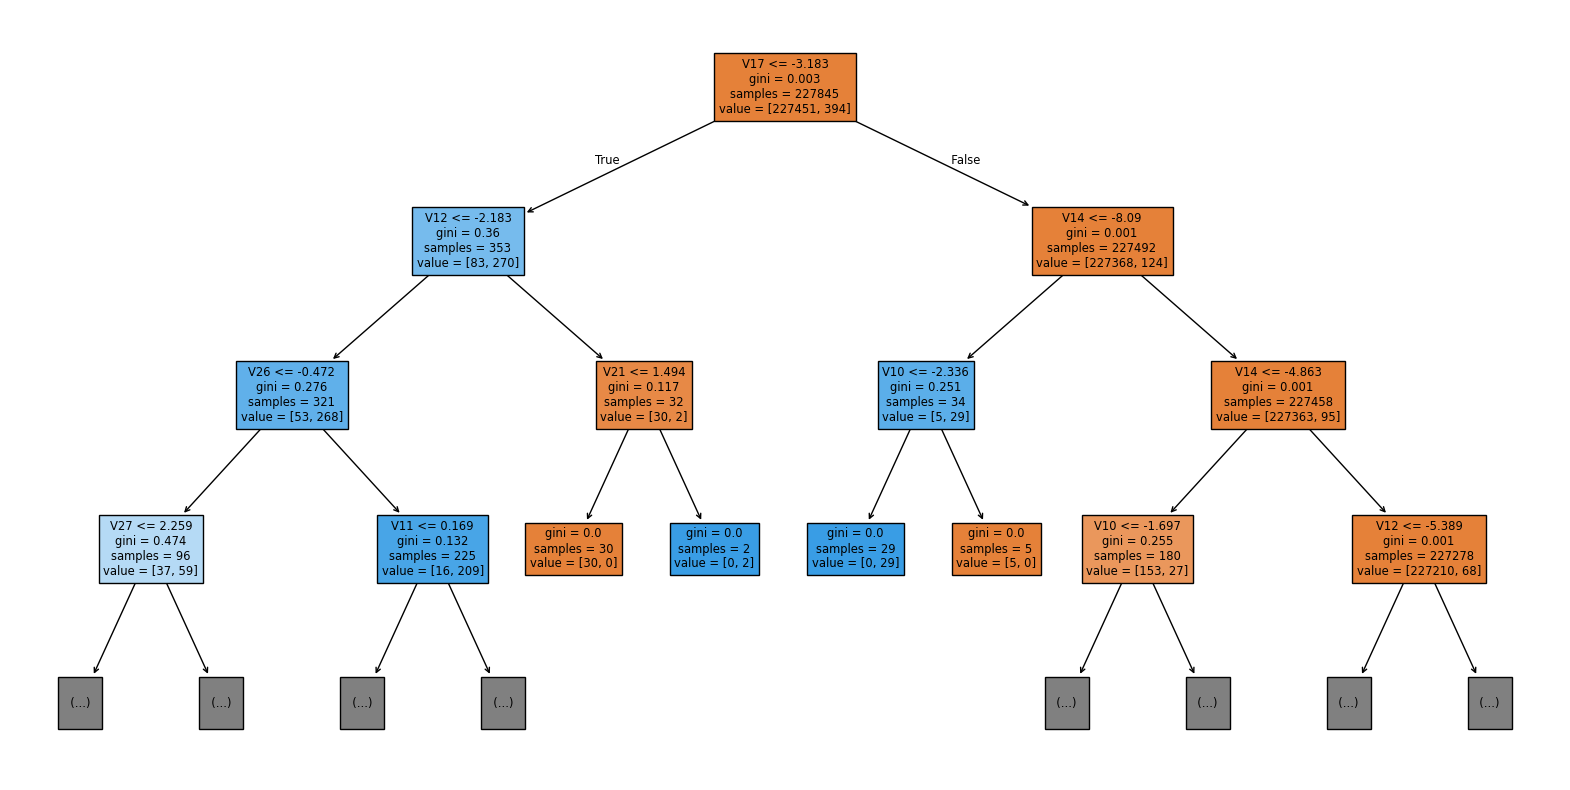

In [17]:

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    max_depth=3,
    feature_names=X.columns,
    filled=True
)

plt.show()

10. Validação Cruzada

In [18]:

scores = cross_val_score(tree, X_scaled, y, cv=5, scoring="f1")

print("Scores:", scores)
print("Média:", scores.mean())

Scores: [0.00320445 0.79329609 0.30909091 0.65116279 0.65979381]
Média: 0.48330961092494507


11. Grid Search (Otimização)

In [19]:

param_grid = {
    "max_depth":[3,5,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

print("Melhores parâmetros:", grid.best_params_)

Melhores parâmetros: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}


Avaliação do Modelo Otimizado

In [20]:

y_pred_opt = best_tree.predict(X_test)

print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.78      0.84        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



12. Modelo Avançado — Random Forest

In [21]:

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Avaliação

In [22]:

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



Importância das Features

In [23]:

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(10)

,feature,importance
17,V17,0.170325
14,V14,0.136363
12,V12,0.133326
10,V10,0.074073
16,V16,0.071792
11,V11,0.045277
9,V9,0.031127
4,V4,0.030496
18,V18,0.028156
7,V7,0.024627


13. PCA (Redução de Dimensionalidade)

In [24]:




pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

Visualização PCA

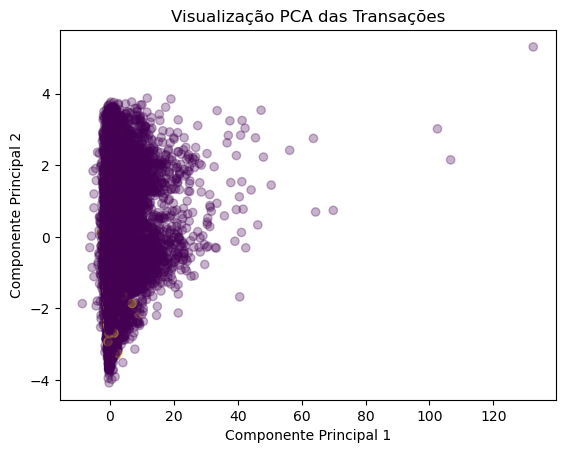

In [25]:

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    alpha=0.3
)

plt.title("Visualização PCA das Transações")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

14. Comparação dos Modelos

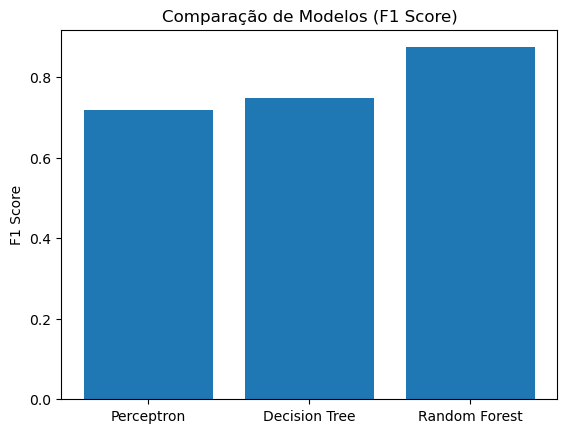

In [26]:

models = ["Perceptron","Decision Tree","Random Forest"]

scores = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_tree),
    f1_score(y_test, y_pred_rf)
]

plt.bar(models, scores)

plt.title("Comparação de Modelos (F1 Score)")
plt.ylabel("F1 Score")

plt.show()